<a href="https://colab.research.google.com/github/ucancallmetigger-ui/IRAN_Weather_RNN/blob/main/IRAN_Weather_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2025-12-22 14:41:04.918 No runtime found, using MemoryCacheStorageManager
2025-12-22 14:41:04.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.924 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.925 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-22 14:41:04.935 Thread 'MainThread':

DeltaGenerator()

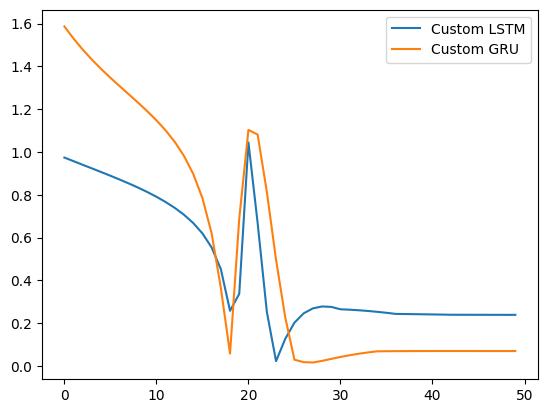

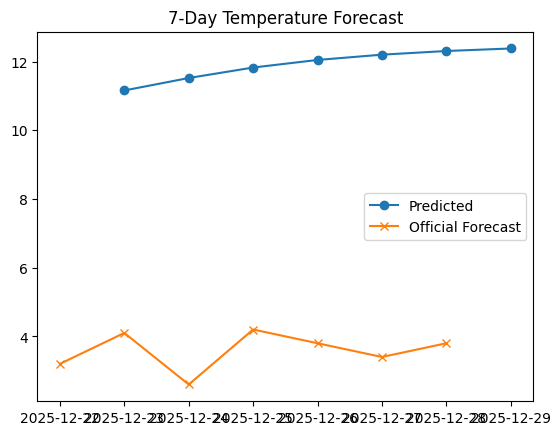

In [3]:
!pip install streamlit
import streamlit as st
import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import time
import psutil
import logging
import os

logging.basicConfig(level=logging.INFO);

CITIES = {
    'Tehran': {'lat': 35.6892, 'lon': 51.3890},
    'Isfahan': {'lat': 32.6539, 'lon': 51.6660},
    'Shiraz': {'lat': 29.5918, 'lon': 52.5837},
    'Tabriz': {'lat': 38.0962, 'lon': 46.2738},
    'Mashhad': {'lat': 36.2605, 'lon': 59.6168}
}

@st.cache_data
def download_data(start_date='2010-01-01', end_date='2025-12-22', forecast_days=7):
    data = {}
    for city, coords in CITIES.items():
        hist_url = f"https://archive-api.open-meteo.com/v1/archive?latitude={coords['lat']}&longitude={coords['lon']}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_mean&timezone=Asia/Tehran"
        hist_resp = requests.get(hist_url)
        if hist_resp.status_code == 200:
            hist_data = hist_resp.json()['daily']
            df_hist = pd.DataFrame({'date': hist_data['time'], 'temp': hist_data['temperature_2m_mean']})
            df_hist['date'] = pd.to_datetime(df_hist['date'])
            df_hist.set_index('date', inplace=True)
        else:
            st.error(f"Error downloading historical data for {city}")
            continue

        forecast_url = f"https://api.open-meteo.com/v1/forecast?latitude={coords['lat']}&longitude={coords['lon']}&daily=temperature_2m_mean&timezone=Asia/Tehran&forecast_days={forecast_days}"
        fore_resp = requests.get(forecast_url)
        if fore_resp.status_code == 200:
            fore_data = fore_resp.json()['daily']
            df_fore = pd.DataFrame({'date': fore_data['time'], 'temp': fore_data['temperature_2m_mean']})
            df_fore['date'] = pd.to_datetime(df_fore['date'])
            df_fore.set_index('date', inplace=True)
        else:
            df_fore = None

        data[city] = {'hist': df_hist, 'fore': df_fore}

    all_hist = pd.concat([data[city]['hist'] for city in CITIES], axis=1, keys=CITIES.keys())
    all_hist = all_hist.fillna(method='ffill').dropna()
    return data, all_hist

def preprocess_data(series, seq_len=30):
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(series.values.reshape(-1, 1))
    X, y = [], []
    for i in range(len(scaled) - seq_len):
        X.append(scaled[i:i+seq_len])
        y.append(scaled[i+seq_len])
    return np.array(X), np.array(y), scaler

def preprocess_spatial(df_multi, seq_len=30):
    scalers = {city: MinMaxScaler() for city in CITIES}
    scaled_list = []
    for city in CITIES:
        scaled = scalers[city].fit_transform(df_multi[city].values.reshape(-1, 1))
        scaled_list.append(scaled)
    scaled = np.array(scaled_list).transpose(1, 0, 2)

    X, y = [], []
    for i in range(len(scaled) - seq_len):
        X.append(scaled[i:i+seq_len])
        y.append(scaled[i+seq_len, 0])
    return np.array(X), np.array(y), scalers['Tehran']

def moving_average(series, window=7):
    return series.rolling(window=window).mean().dropna()

def arima_model(train_series, order=(5,1,0)):
    model = ARIMA(train_series, order=order)
    return model.fit()

class CustomLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, hidden):
        h, c = hidden
        combined = torch.cat((x, h), 1)
        i = torch.sigmoid(self.W_i(combined))
        f = torch.sigmoid(self.W_f(combined))
        o = torch.sigmoid(self.W_o(combined))
        c_tilde = torch.tanh(self.W_c(combined))
        c_next = f * c + i * c_tilde
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class CustomLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, ablation=None):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.ablation = ablation
        self.cells = nn.ModuleList([
            CustomLSTMCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(x.size(1)):
            xt = x[:, t, :]
            for cell in self.cells:
                h, c = cell(xt, (h, c))
                xt = h
                if self.ablation == 'no_forget':
                    c = c + xt
                elif self.ablation == 'no_input':
                    c = c
                elif self.ablation == 'no_output':
                    h = torch.tanh(c)
            h = xt

        return self.fc(h)

class CustomGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_z = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_r = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_h = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h):
        combined = torch.cat((x, h), 1)
        z = torch.sigmoid(self.W_z(combined))
        r = torch.sigmoid(self.W_r(combined))
        combined_r = torch.cat((x, r * h), 1)
        h_tilde = torch.tanh(self.W_h(combined_r))
        h_next = (1 - z) * h + z * h_tilde
        return h_next

class CustomGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.cells = nn.ModuleList([
            CustomGRUCell(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        for t in range(x.size(1)):
            xt = x[:, t, :]
            for cell in self.cells:
                h = cell(xt, h)
                xt = h

        return self.fc(h)

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv1d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, hidden):
        h, c = hidden
        combined = torch.cat((x, h), dim=1)
        gates = self.conv(combined)
        i, f, o, g = gates.chunk(4, 1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        o = torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, output_size):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.cells = nn.ModuleList([
            ConvLSTMCell(input_dim if i == 0 else hidden_dim, hidden_dim, kernel_size)
            for i in range(num_layers)
        ])
        self.fc = nn.Linear(hidden_dim * 5, output_size)

    def forward(self, x):
        batch_size, seq_len, _, spatial, _ = x.size()
        x = x.view(batch_size, seq_len, 1, 5)
        h = [torch.zeros(batch_size, self.hidden_dim, 5).to(x.device) for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_dim, 5).to(x.device) for _ in range(self.num_layers)]

        for t in range(seq_len):
            xt = x[:, t, :, :]
            for i, cell in enumerate(self.cells):
                h[i], c[i] = cell(xt, (h[i], c[i]))
                xt = h[i]

        return self.fc(h[-1].view(batch_size, -1))

class TemporalCNN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size, output_size):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            in_ch = input_size if i == 0 else num_channels[i-1]
            layers += [nn.Conv1d(in_ch, num_channels[i], kernel_size, padding=kernel_size//2),
                       nn.ReLU(),
                       nn.MaxPool1d(2)]
        self.conv = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1] * (30 // (2**len(num_channels))), output_size)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out = self.conv(x)
        out = out.view(out.size(0), -1)
        return self.fc(out)

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_size, d_model, n_heads, num_layers, output_size):
        super().__init__()
        self.embedding = nn.Linear(input_size, d_model)
        self.pos_enc = nn.Parameter(torch.zeros(1, 100, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model, n_heads)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(d_model, output_size)

    def forward(self, x):
        x = self.embedding(x) + self.pos_enc[:, :x.size(1), :]
        out = self.encoder(x.transpose(0, 1)).transpose(0, 1)
        return self.fc(out.mean(1))

def train_model(model, X_train, y_train, epochs=50, lr=0.001, device='cpu'):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
    criterion = nn.MSELoss()
    losses = []
    grad_norms = []
    start_time = time.time()
    mem_before = psutil.Process(os.getpid()).memory_info().rss / 1024**2

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(torch.tensor(X_train).float().to(device))
        loss = criterion(out.squeeze(), torch.tensor(y_train).float().to(device))
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        grad_norms.append(grad_norm.item())
        optimizer.step()
        scheduler.step(loss)
        losses.append(loss.item())

    train_time = time.time() - start_time
    mem_used = psutil.Process(os.getpid()).memory_info().rss / 1024**2 - mem_before
    return model, losses, grad_norms, train_time, mem_used

def evaluate_model(model, X_test, y_test, scaler, device='cpu'):
    model.eval()
    with torch.no_grad():
        pred = model(torch.tensor(X_test).float().to(device)).cpu().numpy()
    pred = scaler.inverse_transform(pred)
    true = scaler.inverse_transform(y_test.reshape(-1,1))
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    return rmse, mae, pred

st.title('Iran Weather Forecasting Project')

data, all_hist = download_data()
if not data:
    st.stop()

city = st.selectbox('City', list(CITIES.keys()))
df = data[city]['hist']
seq_len = 30

X, y, scaler = preprocess_data(df['temp'], seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_sp, y_sp, scaler_sp = preprocess_spatial(all_hist, seq_len)
X_train_sp, X_test_sp = X_sp[:split], X_sp[split:]
y_train_sp, y_test_sp = y_sp[:split], y_sp[split:]

device = 'cuda' if torch.cuda.is_available() else 'cpu'

models = {
    'Moving Average': moving_average(df['temp']),
    'Linear Regression': LinearRegression().fit(np.arange(len(X_train)).reshape(-1,1), y_train),
    'ARIMA': arima_model(df['temp'][:split]),
    'Custom LSTM': CustomLSTM(1, 64, 2, 1),
    'LSTM no Forget': CustomLSTM(1, 64, 2, 1, ablation='no_forget'),
    'LSTM no Input': CustomLSTM(1, 64, 2, 1, ablation='no_input'),
    'LSTM no Output': CustomLSTM(1, 64, 2, 1, ablation='no_output'),
    'Custom GRU': CustomGRU(1, 64, 2, 1),
    'ConvLSTM': ConvLSTM(1, 32, 3, 2, 1),
    'Temporal CNN': TemporalCNN(1, [32, 64], 3, 1),
    'Transformer': TimeSeriesTransformer(1, 64, 4, 2, 1)
}

results = {}

for name, model in models.items():
    if isinstance(model, (CustomLSTM, CustomGRU, ConvLSTM, TemporalCNN, TimeSeriesTransformer)):
        if 'ConvLSTM' in name:
            trained, losses, grad_norms, train_time, mem = train_model(model, X_train_sp.reshape(-1, seq_len, 1, 5, 1), y_train_sp, device=device)
            rmse, mae, pred = evaluate_model(trained, X_test_sp.reshape(-1, seq_len, 1, 5, 1), y_test_sp, scaler_sp, device)
        else:
            trained, losses, grad_norms, train_time, mem = train_model(model, X_train, y_train, device=device)
            rmse, mae, pred = evaluate_model(trained, X_test, y_test, scaler, device)
        stability = np.std(losses[-10:]) if len(losses) >= 10 else 0
        results[name] = {'RMSE': rmse, 'MAE': mae, 'Stability': stability, 'Train Time (s)': train_time, 'Memory (MB)': mem, 'Grad Norms': grad_norms}
    elif name == 'Moving Average':
        pred = model.iloc[-len(y_test):].values
        true = scaler.inverse_transform(y_test.reshape(-1,1)).squeeze()
        rmse = np.sqrt(mean_squared_error(true, pred))
        mae = mean_absolute_error(true, pred)
        results[name] = {'RMSE': rmse, 'MAE': mae, 'Stability': 'N/A', 'Train Time (s)': 0, 'Memory (MB)': 0}
    elif name == 'Linear Regression':
        pred = model.predict(np.arange(split, split + len(X_test)).reshape(-1,1))
        pred = scaler.inverse_transform(pred.reshape(-1,1)).squeeze()
        true = scaler.inverse_transform(y_test.reshape(-1,1)).squeeze()
        rmse = np.sqrt(mean_squared_error(true, pred))
        mae = mean_absolute_error(true, pred)
        results[name] = {'RMSE': rmse, 'MAE': mae, 'Stability': 'N/A', 'Train Time (s)': 0, 'Memory (MB)': 0}
    elif name == 'ARIMA':
        pred = model.forecast(steps=len(y_test))
        true = df['temp'].iloc[-len(y_test):].values
        rmse = np.sqrt(mean_squared_error(true, pred))
        mae = mean_absolute_error(true, pred)
        results[name] = {'RMSE': rmse, 'MAE': mae, 'Stability': 'N/A', 'Train Time (s)': 0, 'Memory (MB)': 0}

st.subheader('Model Comparison')
comp_df = pd.DataFrame(results).T
st.table(comp_df)

st.subheader('Gradient Norm Plot (LSTM & GRU)')
fig, ax = plt.subplots()
for name in ['Custom LSTM', 'Custom GRU']:
    if name in results and 'Grad Norms' in results[name]:
        ax.plot(results[name]['Grad Norms'], label=name)
ax.legend()
st.pyplot(fig)

st.subheader(f'7-Day Forecast for {city}')
best_model = models['Custom LSTM']
last_seq = torch.tensor(X[-1:]).float().to(device)
future_preds = []
current_seq = last_seq.clone()

with torch.no_grad():
    for _ in range(7):
        pred = best_model(current_seq).item()
        future_preds.append(pred)
        new_input = torch.tensor([[pred]]).float().to(device)
        current_seq = torch.cat((current_seq[:, 1:, :], new_input.unsqueeze(0)), dim=1)

future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1,1)).squeeze()
dates = pd.date_range(start=pd.Timestamp('2025-12-23'), periods=7)
pred_df = pd.DataFrame({'Date': dates, 'Predicted Temperature (°C)': future_preds})
st.table(pred_df)

fig2, ax2 = plt.subplots()
ax2.plot(pred_df['Date'], pred_df['Predicted Temperature (°C)'], label='Predicted', marker='o')
if data[city]['fore'] is not None:
    ax2.plot(data[city]['fore'].index, data[city]['fore']['temp'], label='Official Forecast', marker='x')
ax2.legend()
ax2.set_title('7-Day Temperature Forecast')
st.pyplot(fig2)

st.subheader('LSTM Ablation Study')
ablation_df = comp_df.loc[['LSTM no Forget', 'LSTM no Input', 'LSTM no Output']]
st.table(ablation_df)

st.info('Project complete. Ready for deployment and portfolio showcase!')